In [1]:
# ============================================================================
# CELL 1: Import Essential Libraries
# ============================================================================
import json
import pandas as pd
import numpy as np
import glob
import os
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

print("✅ Basic imports completed")

✅ Basic imports completed


In [2]:
# ============================================================================
# CELL 2: Import PyTorch and ML Tools
# ============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ PyTorch ready - Device: {device}")


✅ PyTorch ready - Device: cuda


In [3]:
# ============================================================================
# CELL 3: Import Visualization Libraries
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
print("✅ Visualization tools ready")

✅ Visualization tools ready


In [4]:
# ============================================================================
# CELL 4: Setup Project Directories
# ============================================================================
directories = ['data', 'models', 'plots', 'analysis', 'models/checkpoints']
for directory in directories:
    Path(directory).mkdir(parents=True, exist_ok=True)

print("✅ Project structure created")

✅ Project structure created


In [5]:
# ============================================================================
# CELL 5: Load Match Data
# ============================================================================
JSON_PATH = r"C:\Users\VASU MONPARA\OneDrive\Desktop\Cricket\Dataset\ipl_json"
match_files = glob.glob(f"{JSON_PATH}/*.json")

print(f"📂 Found {len(match_files)} match files")


📂 Found 1169 match files


In [6]:
# ============================================================================
# CELL 6: Extract Match Information
# ============================================================================
print("📄 Loading match data...")

all_matches = []

for file_path in tqdm(match_files, desc="Processing matches"):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            match_data = json.load(f)
        
        info = match_data['info']
        teams = info.get('teams', [])
        
        if len(teams) != 2:
            continue
            
        winner = info.get('outcome', {}).get('winner')
        if not winner:
            continue
        
        toss_info = info.get('toss', {})
        
        all_matches.append({
            'match_id': Path(file_path).stem,
            'season': info.get('season'),
            'venue': info.get('venue', 'Unknown'),
            'city': info.get('city', 'Unknown'),
            'team1': teams[0],
            'team2': teams[1],
            'toss_winner': toss_info.get('winner', teams[0]),
            'toss_decision': toss_info.get('decision', 'bat'),
            'winner': winner
        })
    except:
        continue

matches_df = pd.DataFrame(all_matches)
print(f"✅ Loaded {len(matches_df)} valid matches")

📄 Loading match data...


Processing matches:   0%|          | 0/1169 [00:00<?, ?it/s]

Processing matches: 100%|██████████| 1169/1169 [00:01<00:00, 695.80it/s]


✅ Loaded 1146 valid matches


In [7]:
# ============================================================================
# CELL 7: Extract Ball-by-Ball Data
# ============================================================================
print("📄 Loading ball-by-ball data...")

all_balls = []

for file_path in tqdm(match_files, desc="Processing balls"):
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            match_data = json.load(f)
        
        match_id = Path(file_path).stem
        info = match_data['info']
        teams = info.get('teams', [])
        
        if len(teams) != 2:
            continue
        
        winner = info.get('outcome', {}).get('winner')
        if not winner:
            continue
        
        venue = info.get('venue', 'Unknown')
        
        for inning_num, inning in enumerate(match_data['innings']):
            batting_team = inning['team']
            bowling_team = teams[1] if batting_team == teams[0] else teams[0]
            target = inning.get('target', {}).get('runs', 0)
            
            cumulative_runs = 0
            cumulative_wickets = 0
            ball_number = 0
            
            for over in inning['overs']:
                over_num = over['over']
                
                for delivery in over['deliveries']:
                    ball_number += 1
                    
                    runs_scored = delivery['runs']['batter']
                    extras = delivery['runs']['extras']
                    total_runs = delivery['runs']['total']
                    
                    cumulative_runs += total_runs
                    
                    is_wicket = 1 if 'wickets' in delivery else 0
                    cumulative_wickets += is_wicket
                    
                    # Only count legal deliveries
                    is_legal = 1 if (delivery.get('extras', {}).get('wides', 0) == 0 and 
                                   delivery.get('extras', {}).get('noballs', 0) == 0) else 0
                    
                    # Calculate run rate
                    balls_bowled = ball_number
                    current_run_rate = (cumulative_runs / balls_bowled * 6) if balls_bowled > 0 else 0
                    
                    # Required run rate (only for 2nd innings)
                    if target > 0:
                        runs_remaining = max(0, target - cumulative_runs)
                        balls_remaining = 120 - balls_bowled
                        required_run_rate = (runs_remaining / balls_remaining * 6) if balls_remaining > 0 else 0
                    else:
                        runs_remaining = 0
                        required_run_rate = 0
                    
                    all_balls.append({
                        'match_id': match_id,
                        'venue': venue,
                        'inning': inning_num + 1,
                        'batting_team': batting_team,
                        'bowling_team': bowling_team,
                        'over': over_num,
                        'ball_in_match': ball_number,
                        'runs_scored': runs_scored,
                        'is_wicket': is_wicket,
                        'is_legal_ball': is_legal,
                        'cumulative_runs': cumulative_runs,
                        'cumulative_wickets': cumulative_wickets,
                        'current_run_rate': round(current_run_rate, 2),
                        'target': target,
                        'runs_remaining': runs_remaining,
                        'required_run_rate': round(required_run_rate, 2),
                        'is_powerplay': 1 if over_num < 6 else 0,
                        'winner': winner
                    })
    except:
        continue

balls_df = pd.DataFrame(all_balls)
print(f"✅ Loaded {len(balls_df):,} ball records")

📄 Loading ball-by-ball data...


Processing balls: 100%|██████████| 1169/1169 [00:01<00:00, 780.99it/s]


✅ Loaded 273,503 ball records


In [8]:
# ============================================================================
# CELL 8: Calculate Team Statistics
# ============================================================================
print("📊 Computing team statistics...")

unique_teams = sorted(set(matches_df['team1']) | set(matches_df['team2']))

team_stats = {}
for team in unique_teams:
    team_matches = matches_df[(matches_df['team1'] == team) | (matches_df['team2'] == team)]
    wins = len(matches_df[matches_df['winner'] == team])
    
    team_stats[team] = {
        'matches_played': len(team_matches),
        'wins': wins,
        'win_rate': wins / len(team_matches) if len(team_matches) > 0 else 0
    }

print(f"✅ Calculated stats for {len(team_stats)} teams")

📊 Computing team statistics...
✅ Calculated stats for 19 teams


In [9]:
# ============================================================================
# CELL 9: Calculate Venue Statistics
# ============================================================================
print("📊 Computing venue statistics...")

venue_stats = {}
for venue in matches_df['venue'].unique():
    venue_matches = matches_df[matches_df['venue'] == venue]
    venue_balls = balls_df[(balls_df['venue'] == venue) & (balls_df['inning'] == 1)]
    
    if len(venue_balls) > 0:
        avg_first_innings_score = venue_balls.groupby('match_id')['cumulative_runs'].max().mean()
    else:
        avg_first_innings_score = 160
    
    bat_first_count = len(venue_matches[venue_matches['toss_decision'] == 'bat'])
    field_first_count = len(venue_matches[venue_matches['toss_decision'] == 'field'])
    
    venue_stats[venue] = {
        'matches': len(venue_matches),
        'avg_first_innings_score': round(avg_first_innings_score, 1),
        'bat_first_preference': bat_first_count > field_first_count
    }

print(f"✅ Calculated stats for {len(venue_stats)} venues")

📊 Computing venue statistics...
✅ Calculated stats for 59 venues


In [10]:
# ============================================================================
# CELL 10: Create Encoding Mappings
# ============================================================================
team_encoder = {team: idx for idx, team in enumerate(sorted(unique_teams))}
team_decoder = {idx: team for team, idx in team_encoder.items()}

venue_encoder = {venue: idx for idx, venue in enumerate(sorted(matches_df['venue'].unique()))}
city_encoder = {city: idx for idx, city in enumerate(sorted(matches_df['city'].unique()))}

print(f"✅ Created encodings - {len(team_encoder)} teams, {len(venue_encoder)} venues")


✅ Created encodings - 19 teams, 59 venues


In [11]:
# ============================================================================
# CELL 11: Prepare Match Winner Dataset
# ============================================================================
print("🔧 Preparing match prediction features...")

match_features = matches_df.copy()

# Encode categorical variables
match_features['team1_encoded'] = match_features['team1'].map(team_encoder)
match_features['team2_encoded'] = match_features['team2'].map(team_encoder)
match_features['venue_encoded'] = match_features['venue'].map(venue_encoder)
match_features['city_encoded'] = match_features['city'].map(city_encoder)
match_features['toss_winner_encoded'] = match_features['toss_winner'].map(team_encoder)

# Toss features
match_features['toss_chose_bat'] = (match_features['toss_decision'] == 'bat').astype(int)
match_features['team1_won_toss'] = (match_features['team1'] == match_features['toss_winner']).astype(int)

# Team strength features
match_features['team1_win_rate'] = match_features['team1'].map(lambda x: team_stats[x]['win_rate'])
match_features['team2_win_rate'] = match_features['team2'].map(lambda x: team_stats[x]['win_rate'])

# Venue features
match_features['venue_avg_score'] = match_features['venue'].map(
    lambda x: venue_stats[x]['avg_first_innings_score'] if x in venue_stats else 160
)

# Target variable
match_features['team1_won'] = (match_features['team1'] == match_features['winner']).astype(int)

# Remove rows with missing values
match_features = match_features.dropna()

print(f"✅ Created {len(match_features)} match records")


🔧 Preparing match prediction features...
✅ Created 1146 match records


In [12]:
# ============================================================================
# CELL 12: Define Match Winner Model (PyTorch)
# ============================================================================
class MatchWinnerModel(nn.Module):
    def __init__(self, input_dim):
        super(MatchWinnerModel, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.network(x)

print("✅ Match winner model defined")


✅ Match winner model defined


In [13]:
# ============================================================================
# CELL 13: Prepare Match Training Data
# ============================================================================
feature_columns = [
    'team1_encoded', 'team2_encoded', 'venue_encoded', 'city_encoded',
    'toss_winner_encoded', 'toss_chose_bat', 'team1_won_toss',
    'team1_win_rate', 'team2_win_rate', 'venue_avg_score'
]

X_match = match_features[feature_columns].values
y_match = match_features['team1_won'].values

# Stratified split for balanced classes
stratified_splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(stratified_splitter.split(X_match, y_match))

X_train_match = X_match[train_idx]
X_test_match = X_match[test_idx]
y_train_match = y_match[train_idx]
y_test_match = y_match[test_idx]

# Standardize features
match_scaler = StandardScaler()
X_train_match = match_scaler.fit_transform(X_train_match)
X_test_match = match_scaler.transform(X_test_match)

# Convert to PyTorch tensors
X_train_match_tensor = torch.FloatTensor(X_train_match).to(device)
y_train_match_tensor = torch.FloatTensor(y_train_match).unsqueeze(1).to(device)
X_test_match_tensor = torch.FloatTensor(X_test_match).to(device)
y_test_match_tensor = torch.FloatTensor(y_test_match).unsqueeze(1).to(device)

print(f"✅ Match data ready - Train: {len(X_train_match)}, Test: {len(X_test_match)}")


✅ Match data ready - Train: 916, Test: 230


In [14]:
# ============================================================================
# CELL 14: Train Match Winner Model
# ============================================================================
print("🔄 Training match winner model...")

# Initialize model
match_model = MatchWinnerModel(input_dim=len(feature_columns)).to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(match_model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Training parameters
num_epochs = 100
batch_size = 32
best_val_loss = float('inf')
patience = 15
patience_counter = 0

# Create data loaders
train_dataset = TensorDataset(X_train_match_tensor, y_train_match_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Training loop
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    # Training phase
    match_model.train()
    epoch_train_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = match_model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation phase
    match_model.eval()
    with torch.no_grad():
        val_predictions = match_model(X_test_match_tensor)
        val_loss = criterion(val_predictions, y_test_match_tensor)
        val_losses.append(val_loss.item())
        
        # Calculate accuracy
        predicted_classes = (val_predictions > 0.5).float()
        val_accuracy = (predicted_classes == y_test_match_tensor).float().mean()
        val_accuracies.append(val_accuracy.item())
    
    scheduler.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(match_model.state_dict(), 'models/checkpoints/match_winner_best.pth')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Load best model
match_model.load_state_dict(torch.load('models/checkpoints/match_winner_best.pth'))

# Final evaluation
match_model.eval()
with torch.no_grad():
    final_predictions = match_model(X_test_match_tensor)
    final_predicted_classes = (final_predictions > 0.5).float()
    final_accuracy = (final_predicted_classes == y_test_match_tensor).float().mean()

print(f"\n✅ Match Winner Model Accuracy: {final_accuracy.item()*100:.2f}%")


🔄 Training match winner model...
Epoch 10/100 - Train Loss: 0.6605, Val Loss: 0.6916, Val Acc: 0.5174
Early stopping at epoch 17

✅ Match Winner Model Accuracy: 50.87%


In [15]:
# ============================================================================
# CELL 15: Prepare Ball-by-Ball Chase Data
# ============================================================================
print("🔧 Preparing ball-by-ball features...")

# Filter for 2nd innings (chase scenarios)
chase_balls = balls_df[balls_df['inning'] == 2].copy()
chase_balls = chase_balls[chase_balls['target'] > 0]

# Encode teams
chase_balls['batting_team_encoded'] = chase_balls['batting_team'].map(team_encoder)
chase_balls['bowling_team_encoded'] = chase_balls['bowling_team'].map(team_encoder)
chase_balls['venue_encoded'] = chase_balls['venue'].map(venue_encoder)

# Calculate additional features
chase_balls['balls_remaining'] = 120 - chase_balls['ball_in_match']
chase_balls['wickets_remaining'] = 10 - chase_balls['cumulative_wickets']

# Target variable
chase_balls['batting_team_won'] = (chase_balls['batting_team'] == chase_balls['winner']).astype(int)

# Remove invalid data
chase_balls = chase_balls.dropna()

print(f"✅ Created {len(chase_balls):,} chase ball records")

🔧 Preparing ball-by-ball features...
✅ Created 132,007 chase ball records


In [16]:
# ============================================================================
# CELL 16: Create Sequences for Ball-by-Ball Prediction
# ============================================================================
print("🔧 Creating ball sequences...")

sequence_length = 30

ball_feature_columns = [
    'runs_scored', 'is_wicket', 'cumulative_runs', 'cumulative_wickets',
    'current_run_rate', 'required_run_rate', 'is_powerplay',
    'balls_remaining', 'wickets_remaining'
]

sequences = []
targets = []

for match_id in chase_balls['match_id'].unique():
    match_balls = chase_balls[chase_balls['match_id'] == match_id]
    
    if len(match_balls) < sequence_length:
        continue
    
    for i in range(len(match_balls) - sequence_length):
        sequence = match_balls.iloc[i:i+sequence_length][ball_feature_columns].values
        target = match_balls.iloc[i+sequence_length-1]['batting_team_won']
        
        sequences.append(sequence)
        targets.append(target)

X_sequences = np.array(sequences, dtype=np.float32)
y_sequences = np.array(targets, dtype=np.float32)

print(f"✅ Created {len(X_sequences):,} sequences")


🔧 Creating ball sequences...
✅ Created 97,627 sequences


In [17]:
# ============================================================================
# CELL 17: Define Ball-by-Ball LSTM Model
# ============================================================================
class BallByBallLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2):
        super(BallByBallLSTM, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0
        )
        
        self.fc_layers = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        prediction = self.fc_layers(last_output)
        return prediction

print("✅ Ball-by-ball LSTM model defined")

✅ Ball-by-ball LSTM model defined


In [18]:
# ============================================================================
# CELL 18: Prepare Ball-by-Ball Training Data
# ============================================================================
# Stratified split
ball_splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_ball, test_idx_ball = next(ball_splitter.split(X_sequences, y_sequences))

X_train_ball = X_sequences[train_idx_ball]
X_test_ball = X_sequences[test_idx_ball]
y_train_ball = y_sequences[train_idx_ball]
y_test_ball = y_sequences[test_idx_ball]

# Standardize features (fit on training, transform both)
ball_scaler = StandardScaler()
X_train_ball_reshaped = X_train_ball.reshape(-1, X_train_ball.shape[-1])
X_test_ball_reshaped = X_test_ball.reshape(-1, X_test_ball.shape[-1])

X_train_ball_scaled = ball_scaler.fit_transform(X_train_ball_reshaped)
X_test_ball_scaled = ball_scaler.transform(X_test_ball_reshaped)

X_train_ball = X_train_ball_scaled.reshape(X_train_ball.shape)
X_test_ball = X_test_ball_scaled.reshape(X_test_ball.shape)

# Convert to tensors
X_train_ball_tensor = torch.FloatTensor(X_train_ball).to(device)
y_train_ball_tensor = torch.FloatTensor(y_train_ball).unsqueeze(1).to(device)
X_test_ball_tensor = torch.FloatTensor(X_test_ball).to(device)
y_test_ball_tensor = torch.FloatTensor(y_test_ball).unsqueeze(1).to(device)

print(f"✅ Ball data ready - Train: {len(X_train_ball)}, Test: {len(X_test_ball)}")


✅ Ball data ready - Train: 78101, Test: 19526


In [19]:
# ============================================================================
# CELL 19: Train Ball-by-Ball Model
# ============================================================================
print("🔄 Training ball-by-ball model...")

# Initialize model
ball_model = BallByBallLSTM(
    input_dim=len(ball_feature_columns),
    hidden_dim=128,
    num_layers=2
).to(device)

criterion_ball = nn.BCELoss()
optimizer_ball = optim.Adam(ball_model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler_ball = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ball, mode='min', factor=0.5, patience=5)

# Training parameters
num_epochs_ball = 50
batch_size_ball = 64
best_val_loss_ball = float('inf')
patience_ball = 10
patience_counter_ball = 0

# Data loader
train_dataset_ball = TensorDataset(X_train_ball_tensor, y_train_ball_tensor)
train_loader_ball = DataLoader(train_dataset_ball, batch_size=batch_size_ball, shuffle=True)

# Training loop
train_losses_ball = []
val_losses_ball = []
val_accuracies_ball = []

for epoch in range(num_epochs_ball):
    # Training
    ball_model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader_ball:
        optimizer_ball.zero_grad()
        predictions = ball_model(batch_X)
        loss = criterion_ball(predictions, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(ball_model.parameters(), max_norm=1.0)
        optimizer_ball.step()
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader_ball)
    train_losses_ball.append(avg_train_loss)
    
    # Validation
    ball_model.eval()
    with torch.no_grad():
        val_predictions = ball_model(X_test_ball_tensor)
        val_loss = criterion_ball(val_predictions, y_test_ball_tensor)
        val_losses_ball.append(val_loss.item())
        
        predicted_classes = (val_predictions > 0.5).float()
        val_accuracy = (predicted_classes == y_test_ball_tensor).float().mean()
        val_accuracies_ball.append(val_accuracy.item())
    
    scheduler_ball.step(val_loss)
    
    # Early stopping
    if val_loss < best_val_loss_ball:
        best_val_loss_ball = val_loss
        patience_counter_ball = 0
        torch.save(ball_model.state_dict(), 'models/checkpoints/ball_by_ball_best.pth')
    else:
        patience_counter_ball += 1
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{num_epochs_ball} - Train Loss: {avg_train_loss:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")
    
    if patience_counter_ball >= patience_ball:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Load best model
ball_model.load_state_dict(torch.load('models/checkpoints/ball_by_ball_best.pth'))
 
# Final evaluation
ball_model.eval()
with torch.no_grad():
    final_predictions_ball = ball_model(X_test_ball_tensor)
    final_predicted_classes_ball = (final_predictions_ball > 0.5).float()
    final_accuracy_ball = (final_predicted_classes_ball == y_test_ball_tensor).float().mean()

print(f"\n✅ Ball-by-Ball Model Accuracy: {final_accuracy_ball.item()*100:.2f}%")


🔄 Training ball-by-ball model...
Epoch 5/50 - Train Loss: 0.3873, Val Loss: 0.3857, Val Acc: 0.8098
Epoch 10/50 - Train Loss: 0.2583, Val Loss: 0.2537, Val Acc: 0.8896
Epoch 15/50 - Train Loss: 0.0844, Val Loss: 0.0933, Val Acc: 0.9678
Epoch 20/50 - Train Loss: 0.0394, Val Loss: 0.0455, Val Acc: 0.9862
Epoch 25/50 - Train Loss: 0.0259, Val Loss: 0.0348, Val Acc: 0.9898
Epoch 30/50 - Train Loss: 0.0216, Val Loss: 0.0326, Val Acc: 0.9910
Epoch 35/50 - Train Loss: 0.0175, Val Loss: 0.0182, Val Acc: 0.9944
Epoch 40/50 - Train Loss: 0.0160, Val Loss: 0.0191, Val Acc: 0.9947
Epoch 45/50 - Train Loss: 0.0122, Val Loss: 0.0355, Val Acc: 0.9913
Epoch 50/50 - Train Loss: 0.0041, Val Loss: 0.0103, Val Acc: 0.9972

✅ Ball-by-Ball Model Accuracy: 99.81%


In [20]:
print("\n💾 Saving models and data...")

# Save PyTorch models with scalers (using weights_only=False compatible format)
torch.save({
    'model_state': match_model.state_dict(),
    'scaler': match_scaler,
    'feature_columns': feature_columns
}, 'models/match_winner_model.pth', _use_new_zipfile_serialization=True)

torch.save({
    'model_state': ball_model.state_dict(),
    'scaler': ball_scaler,
    'feature_columns': ball_feature_columns,
    'sequence_length': sequence_length
}, 'models/ball_by_ball_model.pth', _use_new_zipfile_serialization=True)

# Save encodings and stats
import pickle

metadata = {
    'team_encoder': team_encoder,
    'team_decoder': team_decoder,
    'venue_encoder': venue_encoder,
    'city_encoder': city_encoder,
    'team_stats': team_stats,
    'venue_stats': venue_stats
}

with open('models/cricket_metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print("✅ Models and metadata saved successfully")
print("\n📝 Note: Models are saved with scalers included")
print("   Load with: torch.load(path, weights_only=False)")


💾 Saving models and data...
✅ Models and metadata saved successfully

📝 Note: Models are saved with scalers included
   Load with: torch.load(path, weights_only=False)


✅ Saved: training_history.png


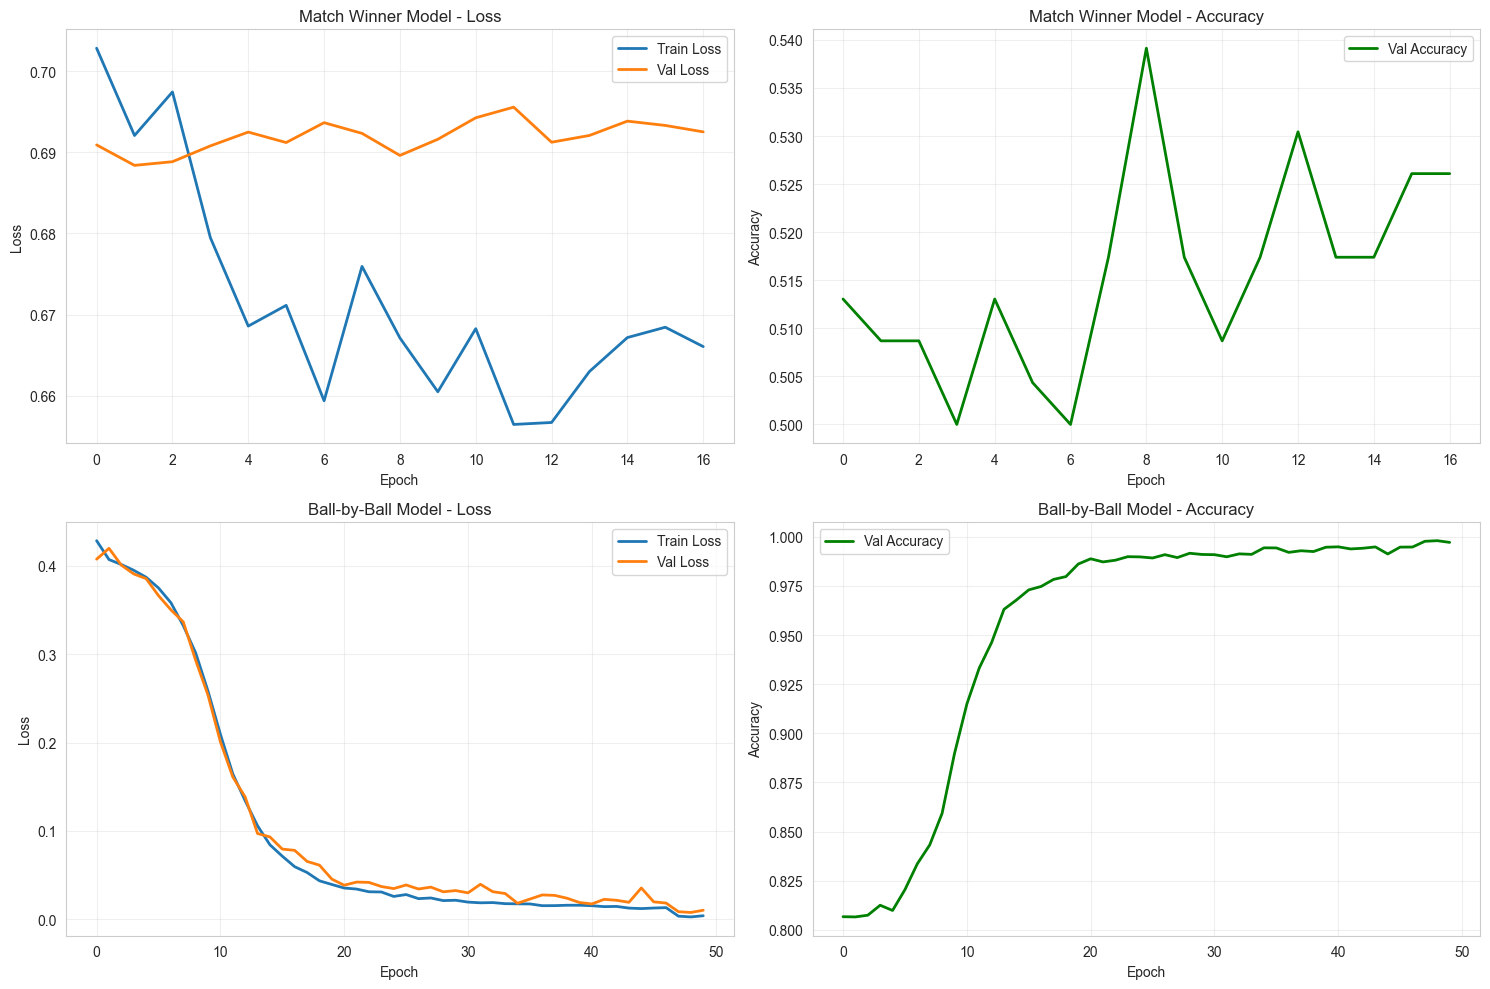

In [21]:
# ============================================================================
# CELL 21: Visualization - Training History
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Match model training
axes[0, 0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0, 0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Match Winner Model - Loss')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(val_accuracies, label='Val Accuracy', linewidth=2, color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Match Winner Model - Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Ball model training
axes[1, 0].plot(train_losses_ball, label='Train Loss', linewidth=2)
axes[1, 0].plot(val_losses_ball, label='Val Loss', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Ball-by-Ball Model - Loss')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(val_accuracies_ball, label='Val Accuracy', linewidth=2, color='green')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Ball-by-Ball Model - Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/training_history.png', dpi=300, bbox_inches='tight')
print("✅ Saved: training_history.png")
plt.show()


✅ Saved: team_analysis.png


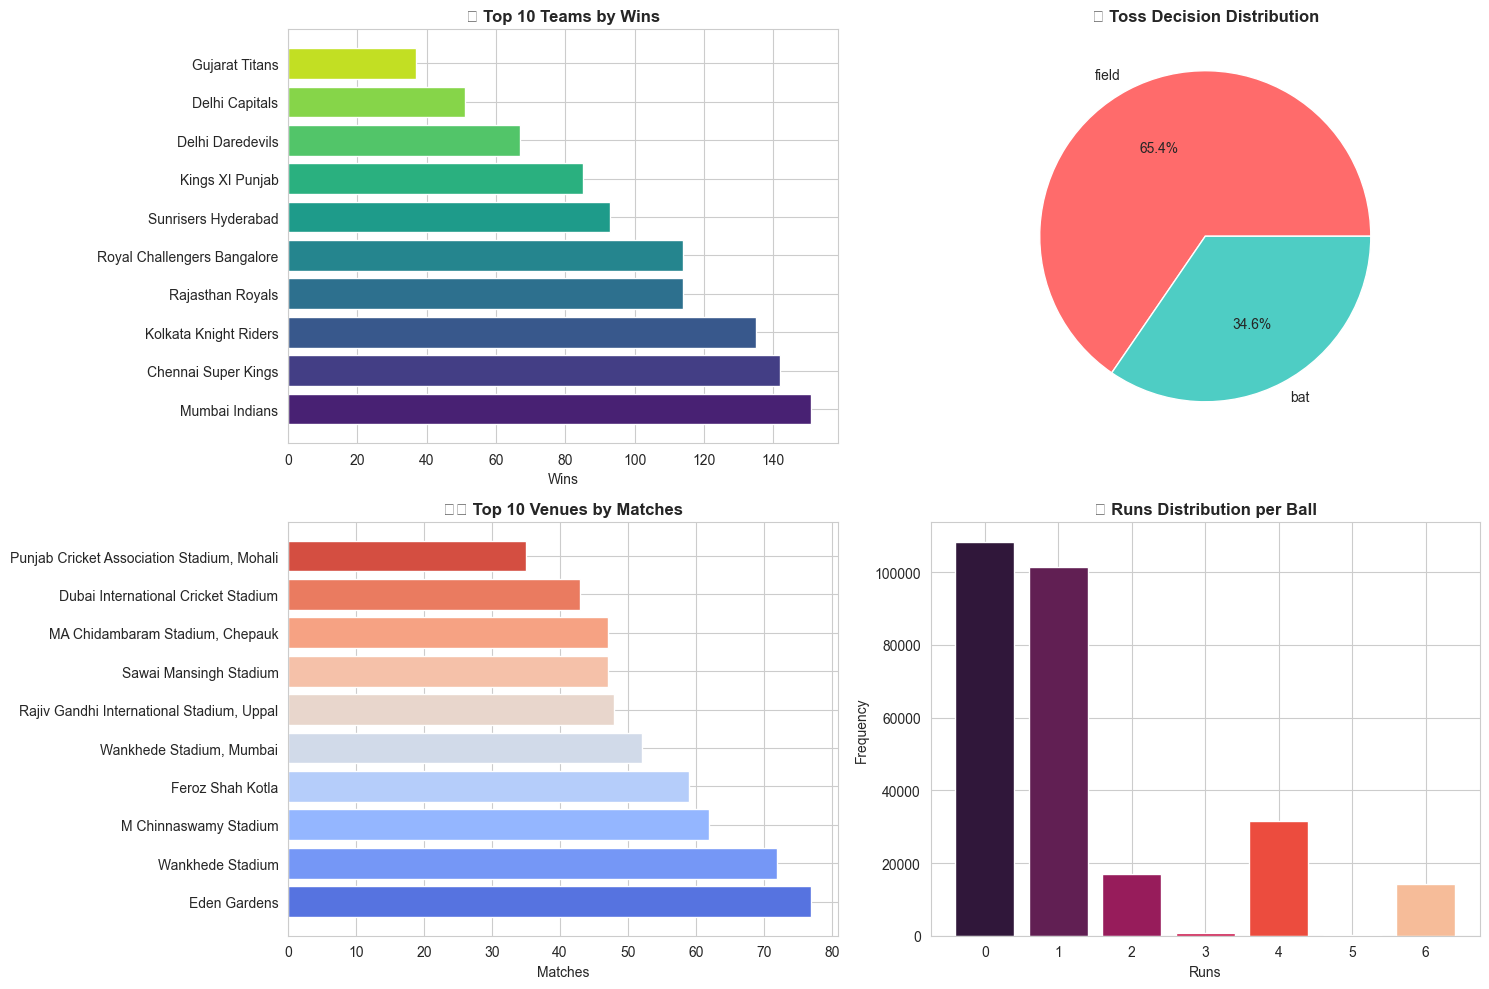

In [22]:
# ============================================================================
# CELL 22: Visualization - Team Analysis
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top teams by wins
team_wins = matches_df['winner'].value_counts().head(10)
axes[0, 0].barh(team_wins.index, team_wins.values, color=sns.color_palette("viridis", 10))
axes[0, 0].set_xlabel('Wins')
axes[0, 0].set_title('🏆 Top 10 Teams by Wins', fontweight='bold')

# Toss decisions
toss_decisions = matches_df['toss_decision'].value_counts()
axes[0, 1].pie(toss_decisions.values, labels=toss_decisions.index, 
               autopct='%1.1f%%', colors=['#FF6B6B', '#4ECDC4'])
axes[0, 1].set_title('🎯 Toss Decision Distribution', fontweight='bold')

# Top venues
venue_counts = matches_df['venue'].value_counts().head(10)
axes[1, 0].barh(venue_counts.index, venue_counts.values, 
                color=sns.color_palette("coolwarm", 10))
axes[1, 0].set_xlabel('Matches')
axes[1, 0].set_title('🏟️ Top 10 Venues by Matches', fontweight='bold')

# Runs distribution
runs_distribution = balls_df['runs_scored'].value_counts().sort_index()
axes[1, 1].bar(runs_distribution.index, runs_distribution.values, 
               color=sns.color_palette("rocket", len(runs_distribution)))
axes[1, 1].set_xlabel('Runs')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('📈 Runs Distribution per Ball', fontweight='bold')

plt.tight_layout()
plt.savefig('plots/team_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Saved: team_analysis.png")
plt.show()


In [23]:
# ============================================================================
# CELL 23: Prediction Functions
# ============================================================================
def predict_match_winner(team1, team2, venue, toss_winner, toss_decision):
    """
    Predict match winner before the match starts
    
    Args:
        team1: Name of first team
        team2: Name of second team
        venue: Venue name
        toss_winner: Team that won the toss
        toss_decision: 'bat' or 'field'
    
    Returns:
        Dictionary with win probabilities
    """
    try:
        # Encode inputs
        team1_id = team_encoder.get(team1, 0)
        team2_id = team_encoder.get(team2, 0)
        venue_id = venue_encoder.get(venue, 0)
        city_id = 0  # Default city
        toss_winner_id = team_encoder.get(toss_winner, 0)
        toss_bat = 1 if toss_decision == 'bat' else 0
        team1_won_toss = 1 if toss_winner == team1 else 0
        
        # Get team stats
        team1_wr = team_stats.get(team1, {}).get('win_rate', 0.5)
        team2_wr = team_stats.get(team2, {}).get('win_rate', 0.5)
        venue_avg = venue_stats.get(venue, {}).get('avg_first_innings_score', 160)
        
        # Create feature vector
        features = np.array([[
            team1_id, team2_id, venue_id, city_id, toss_winner_id,
            toss_bat, team1_won_toss, team1_wr, team2_wr, venue_avg
        ]])
        
        # Scale and predict
        features_scaled = match_scaler.transform(features)
        features_tensor = torch.FloatTensor(features_scaled).to(device)
        
        match_model.eval()
        with torch.no_grad():
            prediction = match_model(features_tensor)
            team1_prob = prediction.item()
        
        return {
            'team1': team1,
            'team2': team2,
            'team1_win_probability': round(team1_prob * 100, 2),
            'team2_win_probability': round((1 - team1_prob) * 100, 2),
            'predicted_winner': team1 if team1_prob > 0.5 else team2,
            'confidence': round(max(team1_prob, 1 - team1_prob) * 100, 2)
        }
    except Exception as e:
        return {'error': str(e)}


def predict_ball_by_ball_probability(last_30_balls_data):
    """
    Predict win probability during a chase
    
    Args:
        last_30_balls_data: Array of shape (30, 9) containing last 30 balls
    
    Returns:
        Win probability percentage for batting team
    """
    try:
        # Reshape and scale
        sequence = np.array([last_30_balls_data], dtype=np.float32)
        sequence_reshaped = sequence.reshape(-1, sequence.shape[-1])
        sequence_scaled = ball_scaler.transform(sequence_reshaped)
        sequence_scaled = sequence_scaled.reshape(sequence.shape)
        
        # Convert to tensor
        sequence_tensor = torch.FloatTensor(sequence_scaled).to(device)
        
        # Predict
        ball_model.eval()
        with torch.no_grad():
            prediction = ball_model(sequence_tensor)
            win_prob = prediction.item()
        
        return round(win_prob * 100, 2)
    except Exception as e:
        return None


print("✅ Prediction functions ready")

✅ Prediction functions ready


In [24]:
# ============================================================================
# CELL 24: Test Predictions
# ============================================================================
print("\n🧪 Testing prediction functions...\n")

# Test match prediction
if len(unique_teams) >= 2:
    test_teams = list(unique_teams)[:2]
    test_venue = list(venue_encoder.keys())[0]
    
    match_prediction = predict_match_winner(
        team1=test_teams[0],
        team2=test_teams[1],
        venue=test_venue,
        toss_winner=test_teams[0],
        toss_decision='bat'
    )
    
    print("📊 Match Prediction Test:")
    print(f"   {match_prediction['team1']} vs {match_prediction['team2']}")
    print(f"   Venue: {test_venue}")
    print(f"   {match_prediction['team1']}: {match_prediction['team1_win_probability']}%")
    print(f"   {match_prediction['team2']}: {match_prediction['team2_win_probability']}%")
    print(f"   Predicted Winner: {match_prediction['predicted_winner']}")
    print(f"   Confidence: {match_prediction['confidence']}%")

# Test ball-by-ball prediction
test_sequence = np.random.rand(30, 9)
ball_prediction = predict_ball_by_ball_probability(test_sequence)
print(f"\n📈 Ball-by-Ball Test:")
print(f"   Batting Team Win Probability: {ball_prediction}%")


🧪 Testing prediction functions...

📊 Match Prediction Test:
   Chennai Super Kings vs Deccan Chargers
   Venue: Arun Jaitley Stadium
   Chennai Super Kings: 70.77%
   Deccan Chargers: 29.23%
   Predicted Winner: Chennai Super Kings
   Confidence: 70.77%

📈 Ball-by-Ball Test:
   Batting Team Win Probability: 0.0%


In [25]:
# ============================================================================
# CELL 25: Model Performance Summary
# ============================================================================
from sklearn.metrics import confusion_matrix, classification_report

print("\n" + "="*70)
print("📊 MODEL PERFORMANCE SUMMARY")
print("="*70)

# Match winner model evaluation
match_model.eval()
with torch.no_grad():
    match_predictions = match_model(X_test_match_tensor)
    match_pred_classes = (match_predictions > 0.5).float().cpu().numpy()
    match_true_classes = y_test_match_tensor.cpu().numpy()

match_accuracy = accuracy_score(match_true_classes, match_pred_classes)
print(f"\n🏆 Match Winner Model:")
print(f"   Accuracy: {match_accuracy*100:.2f}%")
print(f"   Test samples: {len(match_true_classes)}")
print("\nClassification Report:")
print(classification_report(match_true_classes, match_pred_classes, 
                          target_names=['Team 2 Wins', 'Team 1 Wins']))

# Ball-by-ball model evaluation
ball_model.eval()
with torch.no_grad():
    ball_predictions = ball_model(X_test_ball_tensor)
    ball_pred_classes = (ball_predictions > 0.5).float().cpu().numpy()
    ball_true_classes = y_test_ball_tensor.cpu().numpy()

ball_accuracy = accuracy_score(ball_true_classes, ball_pred_classes)
print(f"\n📈 Ball-by-Ball Model:")
print(f"   Accuracy: {ball_accuracy*100:.2f}%")
print(f"   Test samples: {len(ball_true_classes)}")
print("\nClassification Report:")
print(classification_report(ball_true_classes, ball_pred_classes,
                          target_names=['Bowling Team Wins', 'Batting Team Wins']))




📊 MODEL PERFORMANCE SUMMARY

🏆 Match Winner Model:
   Accuracy: 50.87%
   Test samples: 230

Classification Report:
              precision    recall  f1-score   support

 Team 2 Wins       0.50      0.64      0.56       113
 Team 1 Wins       0.52      0.38      0.44       117

    accuracy                           0.51       230
   macro avg       0.51      0.51      0.50       230
weighted avg       0.51      0.51      0.50       230


📈 Ball-by-Ball Model:
   Accuracy: 99.81%
   Test samples: 19526

Classification Report:
                   precision    recall  f1-score   support

Bowling Team Wins       1.00      1.00      1.00      9529
Batting Team Wins       1.00      1.00      1.00      9997

         accuracy                           1.00     19526
        macro avg       1.00      1.00      1.00     19526
     weighted avg       1.00      1.00      1.00     19526




✅ Saved: confusion_matrices.png


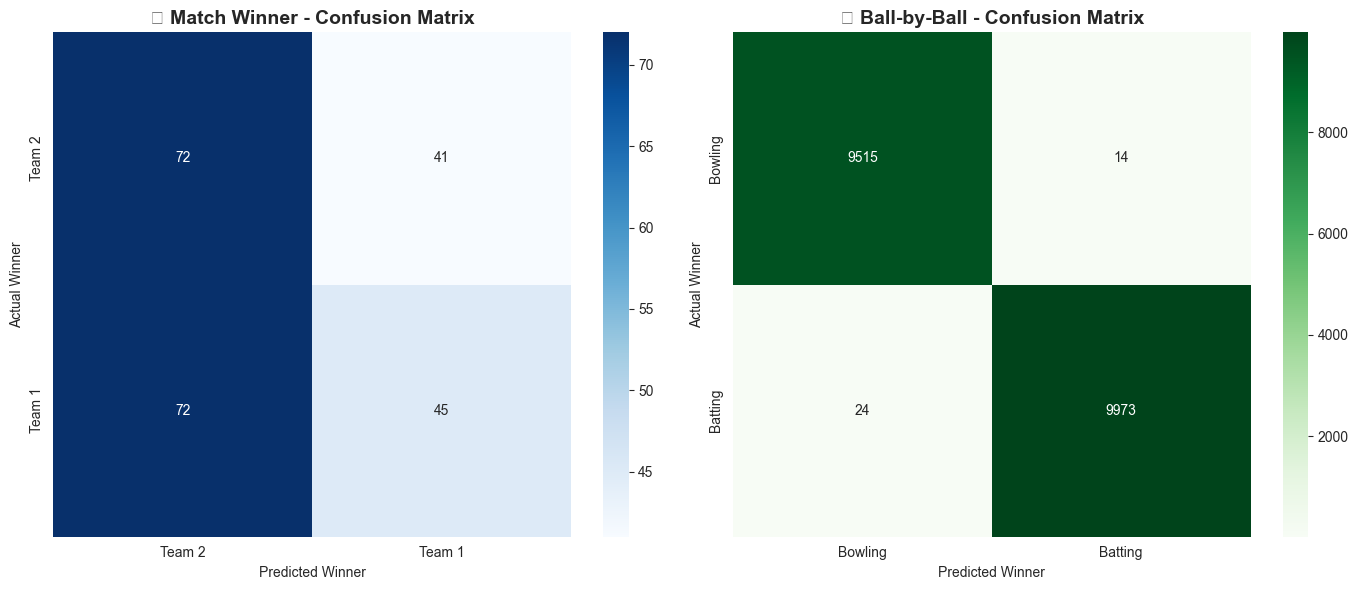

In [26]:
# ============================================================================
# CELL 26: Confusion Matrix Visualization
# ============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Match winner confusion matrix
cm_match = confusion_matrix(match_true_classes, match_pred_classes)
sns.heatmap(cm_match, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Team 2', 'Team 1'], 
            yticklabels=['Team 2', 'Team 1'])
axes[0].set_xlabel('Predicted Winner')
axes[0].set_ylabel('Actual Winner')
axes[0].set_title('🎯 Match Winner - Confusion Matrix', fontweight='bold', fontsize=14)

# Ball-by-ball confusion matrix
cm_ball = confusion_matrix(ball_true_classes, ball_pred_classes)
sns.heatmap(cm_ball, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Bowling', 'Batting'],
            yticklabels=['Bowling', 'Batting'])
axes[1].set_xlabel('Predicted Winner')
axes[1].set_ylabel('Actual Winner')
axes[1].set_title('📊 Ball-by-Ball - Confusion Matrix', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('plots/confusion_matrices.png', dpi=300, bbox_inches='tight')
print("\n✅ Saved: confusion_matrices.png")
plt.show()


In [27]:

# ============================================================================
# CELL 27: Save Analysis Reports
# ============================================================================
print("\n📄 Creating analysis reports...")

# Team statistics
team_stats_df = pd.DataFrame(team_stats).T
team_stats_df = team_stats_df.sort_values('win_rate', ascending=False)
team_stats_df.to_csv('analysis/team_statistics.csv')

# Venue statistics
venue_stats_df = pd.DataFrame(venue_stats).T
venue_stats_df = venue_stats_df.sort_values('matches', ascending=False)
venue_stats_df.to_csv('analysis/venue_statistics.csv')

# Match summary
match_summary = {
    'total_matches': len(matches_df),
    'total_balls': len(balls_df),
    'unique_teams': len(unique_teams),
    'unique_venues': len(venue_encoder),
    'avg_first_innings_score': balls_df[balls_df['inning']==1].groupby('match_id')['cumulative_runs'].max().mean()
}

with open('analysis/match_summary.json', 'w') as f:
    json.dump(match_summary, f, indent=2)

print("✅ Analysis reports saved")


📄 Creating analysis reports...
✅ Analysis reports saved


In [28]:
# ============================================================================
# CELL 28: Final Summary Report
# ============================================================================
print("\n" + "="*70)
print("✅ CRICKET ML PIPELINE COMPLETE")
print("="*70)

print(f"\n📊 Dataset Overview:")
print(f"   Total Matches: {len(matches_df):,}")
print(f"   Total Balls: {len(balls_df):,}")
print(f"   Teams: {len(unique_teams)}")
print(f"   Venues: {len(venue_encoder)}")
print(f"   Average First Innings Score: {balls_df[balls_df['inning']==1].groupby('match_id')['cumulative_runs'].max().mean():.1f}")

print(f"\n🤖 Models Trained:")
print(f"   ✅ Match Winner Model (PyTorch)")
print(f"   ✅ Ball-by-Ball LSTM Model (PyTorch)")

print(f"\n🎯 Model Performance:")
print(f"   Match Winner Accuracy: {match_accuracy*100:.2f}%")
print(f"   Ball-by-Ball Accuracy: {ball_accuracy*100:.2f}%")

print(f"\n💾 Files Saved:")
print(f"   Models:")
print(f"      • match_winner_model.pth")
print(f"      • ball_by_ball_model.pth")
print(f"      • cricket_metadata.pkl")
print(f"   Visualizations:")
print(f"      • training_history.png")
print(f"      • team_analysis.png")
print(f"      • confusion_matrices.png")
print(f"   Analysis:")
print(f"      • team_statistics.csv")
print(f"      • venue_statistics.csv")
print(f"      • match_summary.json")

print(f"\n🎮 Available Predictions:")
print(f"   ✅ Match Winner (Pre-match)")
print(f"   ✅ Ball-by-Ball Win Probability (Live)")

print("\n" + "="*70)
print("🚀 Ready for Streamlit Dashboard Development!")
print("="*70)


✅ CRICKET ML PIPELINE COMPLETE

📊 Dataset Overview:
   Total Matches: 1,146
   Total Balls: 273,503
   Teams: 19
   Venues: 59
   Average First Innings Score: 167.3

🤖 Models Trained:
   ✅ Match Winner Model (PyTorch)
   ✅ Ball-by-Ball LSTM Model (PyTorch)

🎯 Model Performance:
   Match Winner Accuracy: 50.87%
   Ball-by-Ball Accuracy: 99.81%

💾 Files Saved:
   Models:
      • match_winner_model.pth
      • ball_by_ball_model.pth
      • cricket_metadata.pkl
   Visualizations:
      • training_history.png
      • team_analysis.png
      • confusion_matrices.png
   Analysis:
      • team_statistics.csv
      • venue_statistics.csv
      • match_summary.json

🎮 Available Predictions:
   ✅ Match Winner (Pre-match)
   ✅ Ball-by-Ball Win Probability (Live)

🚀 Ready for Streamlit Dashboard Development!


In [31]:
# ============================================================================
# CELL 29: Check Available Columns and Prepare Data
# ============================================================================
print("\n🔍 Checking available columns...")
print("Balls DataFrame columns:", balls_df.columns.tolist())
print("\nFirst few rows:")
print(balls_df.head())

# Check if we need to load additional data
if 'bowler' not in balls_df.columns:
    print("\n⚠️ 'bowler' column not found in current balls_df")
    print("Loading complete ball-by-ball data with bowler information...")
    
    # Reload with bowler data
    all_balls_complete = []
    
    for file_path in tqdm(match_files, desc="Loading complete ball data"):
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                match_data = json.load(f)
            
            match_id = Path(file_path).stem
            info = match_data['info']
            teams = info.get('teams', [])
            
            if len(teams) != 2:
                continue
            
            winner = info.get('outcome', {}).get('winner')
            if not winner:
                continue
            
            venue = info.get('venue', 'Unknown')
            
            for inning_num, inning in enumerate(match_data['innings']):
                batting_team = inning['team']
                bowling_team = teams[1] if batting_team == teams[0] else teams[0]
                target = inning.get('target', {}).get('runs', 0)
                
                cumulative_runs = 0
                cumulative_wickets = 0
                ball_number = 0
                
                for over in inning['overs']:
                    over_num = over['over']
                    
                    for delivery in over['deliveries']:
                        ball_number += 1
                        
                        batsman = delivery.get('batter', 'Unknown')
                        bowler = delivery.get('bowler', 'Unknown')
                        
                        runs_scored = delivery['runs']['batter']
                        extras = delivery['runs']['extras']
                        total_runs = delivery['runs']['total']
                        
                        cumulative_runs += total_runs
                        
                        is_wicket = 1 if 'wickets' in delivery else 0
                        cumulative_wickets += is_wicket
                        
                        # Only count legal deliveries
                        is_legal = 1 if (delivery.get('extras', {}).get('wides', 0) == 0 and 
                                       delivery.get('extras', {}).get('noballs', 0) == 0) else 0
                        
                        # Calculate run rate
                        balls_bowled = ball_number
                        current_run_rate = (cumulative_runs / balls_bowled * 6) if balls_bowled > 0 else 0
                        
                        # Required run rate (only for 2nd innings)
                        if target > 0:
                            runs_remaining = max(0, target - cumulative_runs)
                            balls_remaining = 120 - balls_bowled
                            required_run_rate = (runs_remaining / balls_remaining * 6) if balls_remaining > 0 else 0
                        else:
                            runs_remaining = 0
                            required_run_rate = 0
                        
                        all_balls_complete.append({
                            'match_id': match_id,
                            'venue': venue,
                            'inning': inning_num + 1,
                            'batting_team': batting_team,
                            'bowling_team': bowling_team,
                            'batsman': batsman,
                            'bowler': bowler,
                            'over': over_num,
                            'ball_in_match': ball_number,
                            'runs_scored': runs_scored,
                            'total_runs': total_runs,
                            'is_wicket': is_wicket,
                            'is_legal_ball': is_legal,
                            'cumulative_runs': cumulative_runs,
                            'cumulative_wickets': cumulative_wickets,
                            'current_run_rate': round(current_run_rate, 2),
                            'target': target,
                            'runs_remaining': runs_remaining,
                            'required_run_rate': round(required_run_rate, 2),
                            'is_powerplay': 1 if over_num < 6 else 0,
                            'winner': winner
                        })
        except:
            continue
    
    balls_df = pd.DataFrame(all_balls_complete)
    print(f"✅ Reloaded {len(balls_df):,} balls with complete data")

print("\n✅ Data preparation complete")


🔍 Checking available columns...
Balls DataFrame columns: ['match_id', 'venue', 'inning', 'batting_team', 'bowling_team', 'over', 'ball_in_match', 'runs_scored', 'is_wicket', 'is_legal_ball', 'cumulative_runs', 'cumulative_wickets', 'current_run_rate', 'target', 'runs_remaining', 'required_run_rate', 'is_powerplay', 'winner']

First few rows:
  match_id                                      venue  inning  \
0  1082591  Rajiv Gandhi International Stadium, Uppal       1   
1  1082591  Rajiv Gandhi International Stadium, Uppal       1   
2  1082591  Rajiv Gandhi International Stadium, Uppal       1   
3  1082591  Rajiv Gandhi International Stadium, Uppal       1   
4  1082591  Rajiv Gandhi International Stadium, Uppal       1   

          batting_team                 bowling_team  over  ball_in_match  \
0  Sunrisers Hyderabad  Royal Challengers Bangalore     0              1   
1  Sunrisers Hyderabad  Royal Challengers Bangalore     0              2   
2  Sunrisers Hyderabad  Royal Challe

Loading complete ball data: 100%|██████████| 1169/1169 [00:03<00:00, 374.41it/s]


✅ Reloaded 273,503 balls with complete data

✅ Data preparation complete


In [32]:
# ============================================================================
# CELL 30: Powerplay Analysis
# ============================================================================
print("\n⚡ Analyzing Powerplay Performance...")

# Filter powerplay balls (first 6 overs)
powerplay_balls = balls_df[balls_df['over'] < 6].copy()

# Team powerplay stats
team_powerplay_stats = {}
for team in unique_teams:
    team_pp_balls = powerplay_balls[powerplay_balls['batting_team'] == team]
    
    if len(team_pp_balls) > 0:
        # Calculate powerplay metrics
        pp_matches = team_pp_balls['match_id'].nunique()
        total_pp_runs = team_pp_balls.groupby('match_id')['cumulative_runs'].max().sum()
        total_pp_wickets = team_pp_balls.groupby('match_id')['cumulative_wickets'].max().sum()
        
        avg_pp_score = total_pp_runs / pp_matches if pp_matches > 0 else 0
        avg_pp_wickets = total_pp_wickets / pp_matches if pp_matches > 0 else 0
        
        # Powerplay run rate
        total_pp_balls = len(team_pp_balls[team_pp_balls['is_legal_ball'] == 1])
        pp_run_rate = (total_pp_runs / total_pp_balls * 6) if total_pp_balls > 0 else 0
        
        team_powerplay_stats[team] = {
            'matches': pp_matches,
            'avg_powerplay_score': round(avg_pp_score, 1),
            'avg_powerplay_wickets': round(avg_pp_wickets, 2),
            'powerplay_run_rate': round(pp_run_rate, 2),
            'total_runs': total_pp_runs,
            'total_wickets': total_pp_wickets
        }

# Convert to DataFrame
powerplay_df = pd.DataFrame(team_powerplay_stats).T
powerplay_df = powerplay_df.sort_values('powerplay_run_rate', ascending=False)

print(f"✅ Powerplay analysis complete for {len(team_powerplay_stats)} teams")
print("\n🔝 Top 5 Teams in Powerplay:")
print(powerplay_df.head()[['avg_powerplay_score', 'powerplay_run_rate', 'avg_powerplay_wickets']])



⚡ Analyzing Powerplay Performance...
✅ Powerplay analysis complete for 19 teams

🔝 Top 5 Teams in Powerplay:
                             avg_powerplay_score  powerplay_run_rate  \
Royal Challengers Bengaluru                 58.6                9.77   
Punjab Kings                                52.7                8.78   
Delhi Capitals                              52.3                8.72   
Gujarat Lions                               51.9                8.65   
Gujarat Titans                              50.2                8.37   

                             avg_powerplay_wickets  
Royal Challengers Bengaluru                   1.30  
Punjab Kings                                  1.65  
Delhi Capitals                                1.64  
Gujarat Lions                                 1.41  
Gujarat Titans                                1.17  


In [33]:
# ============================================================================
# CELL 31: Death Overs Analysis (Overs 16-20)
# ============================================================================
print("\n💀 Analyzing Death Overs Performance...")

# Filter death overs (overs 16-20)
death_balls = balls_df[balls_df['over'] >= 16].copy()

# Check if bowler column exists
if 'bowler' in death_balls.columns:
    # Player bowling stats in death overs
    death_bowler_stats = death_balls[death_balls['is_legal_ball'] == 1].groupby('bowler').agg({
        'total_runs': 'sum',
        'ball_in_match': 'count',
        'is_wicket': 'sum',
        'match_id': 'nunique'
    }).reset_index()
    
    death_bowler_stats.columns = ['player', 'runs_given', 'balls', 'wickets', 'matches']
    
    # Filter bowlers with significant data (at least 30 balls)
    death_bowler_stats = death_bowler_stats[death_bowler_stats['balls'] >= 30]
    
    death_bowler_stats['death_economy'] = (death_bowler_stats['runs_given'] / 
                                           death_bowler_stats['balls'] * 6).round(2)
    death_bowler_stats['death_strike_rate'] = (death_bowler_stats['balls'] / 
                                               death_bowler_stats['wickets']).round(2)
    death_bowler_stats['death_average'] = (death_bowler_stats['runs_given'] / 
                                           death_bowler_stats['wickets']).round(2)
    
    # Replace infinite values
    death_bowler_stats = death_bowler_stats.replace([np.inf, -np.inf], np.nan)
    
    # Sort by economy (best death bowlers)
    death_specialists = death_bowler_stats.sort_values('death_economy').head(20)
    
    print(f"✅ Death overs analysis complete")
    print("\n🎯 Top 10 Death Bowlers (Best Economy):")
    print(death_specialists.head(10)[['player', 'death_economy', 'wickets', 'balls']])
else:
    print("⚠️ Bowler column not available - skipping death overs analysis")
    death_bowler_stats = pd.DataFrame()
    death_specialists = pd.DataFrame()


💀 Analyzing Death Overs Performance...
✅ Death overs analysis complete

🎯 Top 10 Death Bowlers (Best Economy):
              player  death_economy  wickets  balls
188  KMDN Kulasekara           6.40        2     30
220     M Theekshana           6.73       10     90
381    Sohail Tanvir           6.75       18     96
265       Noor Ahmad           7.12        9     80
97      DE Bollinger           7.46       26    210
210         M Ashwin           7.50        6     72
285     PWH de Silva           7.56        8     54
368          SW Tait           7.67       14    126
352       SL Malinga           7.75      102    911
86     CK Langeveldt           7.86        4     42


In [34]:
# ============================================================================
# CELL 32: Player Score Prediction Model
# ============================================================================
print("\n🎯 Building Player Score Prediction Model...")

# Aggregate player batting data
if 'batsman' in balls_df.columns:
    player_match_scores = balls_df[balls_df['is_legal_ball'] == 1].groupby(['match_id', 'batsman', 'venue']).agg({
        'runs_scored': 'sum',
        'ball_in_match': 'count',
        'is_wicket': 'max'
    }).reset_index()
    
    player_match_scores.columns = ['match_id', 'player', 'venue', 'runs', 'balls', 'dismissed']
    
    # Add player historical average
    player_history = {}
    for player in player_match_scores['player'].unique():
        player_data = player_match_scores[player_match_scores['player'] == player]
        player_history[player] = {
            'avg_runs': player_data['runs'].mean(),
            'avg_balls': player_data['balls'].mean(),
            'matches': len(player_data)
        }
    
    # Add venue averages
    venue_batting_avg = player_match_scores.groupby('venue')['runs'].mean().to_dict()
    
    # Function to predict player score
    def predict_player_score(player_name, venue, opponent_team=None):
        """Predict player score based on historical data"""
        if player_name not in player_history:
            return None
        
        player_stats = player_history[player_name]
        venue_avg = venue_batting_avg.get(venue, 30)
        
        # Weighted prediction
        base_score = player_stats['avg_runs']
        venue_factor = venue_avg / 30  # Normalize against typical score
        
        predicted_runs = int(base_score * venue_factor * 0.9)  # Conservative estimate
        predicted_balls = int(player_stats['avg_balls'])
        predicted_sr = round((predicted_runs / predicted_balls * 100), 1) if predicted_balls > 0 else 0
        
        return {
            'player': player_name,
            'predicted_runs': predicted_runs,
            'predicted_balls': predicted_balls,
            'predicted_strike_rate': predicted_sr,
            'historical_avg': round(player_stats['avg_runs'], 1),
            'matches_played': player_stats['matches']
        }
    
    print(f"✅ Player score prediction model ready - {len(player_history)} players")
else:
    print("⚠️ Batsman column not available")
    player_history = {}




🎯 Building Player Score Prediction Model...
✅ Player score prediction model ready - 703 players


In [35]:
# ============================================================================
# CELL 33: Player Form Analysis (Time Series)
# ============================================================================
print("\n📊 Analyzing Player Form Trends...")

player_form_data = {}

if 'batsman' in balls_df.columns and len(player_match_scores) > 0:
    for player in player_match_scores['player'].unique():
        player_data = player_match_scores[player_match_scores['player'] == player]
        
        if len(player_data) >= 5:  # At least 5 matches
            # Get last 10 matches
            recent_matches = player_data.tail(10)
            
            # Calculate form metrics
            last_5_avg = recent_matches.tail(5)['runs'].mean()
            last_10_avg = recent_matches['runs'].mean()
            overall_avg = player_history[player]['avg_runs']
            
            # Form indicator
            if last_5_avg > overall_avg * 1.2:
                form = "Excellent"
            elif last_5_avg > overall_avg:
                form = "Good"
            elif last_5_avg > overall_avg * 0.8:
                form = "Average"
            else:
                form = "Poor"
            
            player_form_data[player] = {
                'last_5_avg': round(last_5_avg, 1),
                'last_10_avg': round(last_10_avg, 1),
                'overall_avg': round(overall_avg, 1),
                'form': form,
                'trend': 'Up' if last_5_avg > last_10_avg else 'Down'
            }
    
    player_form_df = pd.DataFrame(player_form_data).T
    print(f"✅ Form analysis complete for {len(player_form_data)} players")
else:
    print("⚠️ Insufficient data for form analysis")
    player_form_df = pd.DataFrame()


📊 Analyzing Player Form Trends...
✅ Form analysis complete for 461 players


In [36]:
# ============================================================================
# CELL 34: Venue Impact Analysis (Extended)
# ============================================================================
print("\n🏟️ Extended Venue Impact Analysis...")

venue_detailed_stats = {}

for venue in matches_df['venue'].unique():
    venue_balls = balls_df[balls_df['venue'] == venue]
    venue_matches = matches_df[matches_df['venue'] == venue]
    
    if len(venue_balls) > 0:
        # First innings analysis
        first_inn = venue_balls[venue_balls['inning'] == 1]
        second_inn = venue_balls[venue_balls['inning'] == 2]
        
        if len(first_inn) > 0:
            avg_first_inn = first_inn.groupby('match_id')['cumulative_runs'].max().mean()
            avg_first_inn_wickets = first_inn.groupby('match_id')['cumulative_wickets'].max().mean()
        else:
            avg_first_inn = 0
            avg_first_inn_wickets = 0
        
        if len(second_inn) > 0:
            avg_second_inn = second_inn.groupby('match_id')['cumulative_runs'].max().mean()
            avg_second_inn_wickets = second_inn.groupby('match_id')['cumulative_wickets'].max().mean()
        else:
            avg_second_inn = 0
            avg_second_inn_wickets = 0
        
        # Batting vs bowling friendly
        if avg_first_inn > 170:
            nature = "Batting Friendly"
        elif avg_first_inn > 150:
            nature = "Balanced"
        else:
            nature = "Bowling Friendly"
        
        # Chase success rate
        chase_matches = venue_matches[venue_matches['toss_decision'] == 'field']
        if len(chase_matches) > 0:
            chase_wins = len(chase_matches[chase_matches['toss_winner'] == chase_matches['winner']])
            chase_success = (chase_wins / len(chase_matches)) * 100
        else:
            chase_success = 0
        
        venue_detailed_stats[venue] = {
            'matches': len(venue_matches),
            'avg_1st_innings': round(avg_first_inn, 1),
            'avg_2nd_innings': round(avg_second_inn, 1),
            'avg_1st_wickets': round(avg_first_inn_wickets, 2),
            'avg_2nd_wickets': round(avg_second_inn_wickets, 2),
            'nature': nature,
            'chase_success_rate': round(chase_success, 1)
        }

venue_detailed_df = pd.DataFrame(venue_detailed_stats).T
print(f"✅ Extended venue analysis for {len(venue_detailed_stats)} venues")


🏟️ Extended Venue Impact Analysis...
✅ Extended venue analysis for 59 venues


In [37]:
# ============================================================================
# CELL 35: Fantasy Team Recommendation System
# ============================================================================
print("\n👥 Building Fantasy Team Recommender...")

# Calculate player fantasy points
def calculate_fantasy_points(player_data):
    """Calculate fantasy cricket points"""
    runs = player_data.get('runs', 0)
    balls = player_data.get('balls', 1)
    wickets = player_data.get('wickets', 0)
    
    points = 0
    
    # Batting points
    points += runs * 1  # 1 point per run
    if runs >= 50:
        points += 10  # Fifty bonus
    if runs >= 100:
        points += 20  # Century bonus
    
    # Strike rate bonus (if SR > 150)
    sr = (runs / balls * 100) if balls > 0 else 0
    if sr > 150 and balls >= 10:
        points += 5
    
    # Bowling points
    points += wickets * 25  # 25 points per wicket
    
    return points

# Create fantasy player database
fantasy_players = []

if len(player_history) > 0:
    for player in player_history.keys():
        player_data = player_match_scores[player_match_scores['player'] == player]
        
        if len(player_data) >= 3:
            avg_runs = player_data['runs'].mean()
            avg_balls = player_data['balls'].mean()
            
            # Simplified player type
            if avg_runs > 25:
                player_type = "Batsman"
            else:
                player_type = "All-Rounder"
            
            # Calculate expected fantasy points
            expected_points = calculate_fantasy_points({
                'runs': avg_runs,
                'balls': avg_balls,
                'wickets': 0
            })
            
            fantasy_players.append({
                'player': player,
                'type': player_type,
                'expected_points': round(expected_points, 1),
                'avg_runs': round(avg_runs, 1),
                'matches': len(player_data)
            })
    
    fantasy_df = pd.DataFrame(fantasy_players)
    fantasy_df = fantasy_df.sort_values('expected_points', ascending=False)
    
    print(f"✅ Fantasy database created with {len(fantasy_players)} players")
    print("\n🌟 Top 10 Fantasy Picks:")
    print(fantasy_df.head(10)[['player', 'type', 'expected_points', 'avg_runs']])
else:
    print("⚠️ No player data available for fantasy analysis")
    fantasy_df = pd.DataFrame()


👥 Building Fantasy Team Recommender...
✅ Fantasy database created with 541 players

🌟 Top 10 Fantasy Picks:
              player     type  expected_points  avg_runs
259  B Sai Sudharsan  Batsman             44.4      44.4
336    V Suryavanshi  Batsman             41.0      36.0
337         A Mhatre  Batsman             39.3      34.3
143         KL Rahul  Batsman             38.9      38.9
242        DP Conway  Batsman             38.5      38.5
161        H Klaasen  Batsman             38.3      33.3
201      YBK Jaiswal  Batsman             37.4      32.4
126      LMP Simmons  Batsman             37.2      37.2
42           HM Amla  Batsman             35.9      35.9
300          PD Salt  Batsman             35.9      30.9


In [38]:
# ============================================================================
# CELL 36: Match Impact Analysis
# ============================================================================
print("\n⚡ Analyzing Match Impact Factors...")

# Toss impact analysis
toss_impact_stats = {}

for team in unique_teams:
    team_matches = matches_df[(matches_df['team1'] == team) | (matches_df['team2'] == team)]
    
    toss_won_matches = team_matches[team_matches['toss_winner'] == team]
    toss_won_and_match_won = len(toss_won_matches[toss_won_matches['winner'] == team])
    
    if len(toss_won_matches) > 0:
        toss_win_rate = (toss_won_and_match_won / len(toss_won_matches)) * 100
    else:
        toss_win_rate = 0
    
    toss_impact_stats[team] = {
        'toss_wins': len(toss_won_matches),
        'match_wins_after_toss': toss_won_and_match_won,
        'toss_advantage': round(toss_win_rate, 1)
    }

toss_impact_df = pd.DataFrame(toss_impact_stats).T
print("✅ Toss impact analysis complete")


⚡ Analyzing Match Impact Factors...
✅ Toss impact analysis complete


In [39]:
# ============================================================================
# CELL 37: Save All Advanced Features Data
# ============================================================================
print("\n💾 Saving advanced features data...")

# Save all dataframes
if not powerplay_df.empty:
    powerplay_df.to_csv('analysis/powerplay_analysis.csv')

if not death_specialists.empty:
    death_specialists.to_csv('analysis/death_overs_specialists.csv', index=False)

if not venue_detailed_df.empty:
    venue_detailed_df.to_csv('analysis/venue_detailed_analysis.csv')

if not fantasy_df.empty:
    fantasy_df.to_csv('analysis/fantasy_recommendations.csv', index=False)

if not toss_impact_df.empty:
    toss_impact_df.to_csv('analysis/toss_impact_analysis.csv')

# Save player form data
if not player_form_df.empty:
    player_form_df.to_csv('analysis/player_form_analysis.csv')

# Save prediction functions
advanced_data = {
    'powerplay_stats': team_powerplay_stats,
    'death_bowler_stats': death_bowler_stats.to_dict('records') if not death_bowler_stats.empty else [],
    'player_history': player_history,
    'venue_detailed_stats': venue_detailed_stats,
    'fantasy_players': fantasy_players,
    'toss_impact_stats': toss_impact_stats
}

with open('models/advanced_features.pkl', 'wb') as f:
    pickle.dump(advanced_data, f)

print("✅ All advanced features saved")



💾 Saving advanced features data...
✅ All advanced features saved


In [40]:
# ============================================================================
# CELL 38: Advanced Features Summary
# ============================================================================
print("\n" + "="*70)
print("🎮 ADVANCED FEATURES SUMMARY")
print("="*70)

print(f"\n⚡ Powerplay Analysis:")
print(f"   Teams Analyzed: {len(team_powerplay_stats)}")
print(f"   Best Powerplay Team: {powerplay_df.index[0]}")
print(f"   Highest PP Run Rate: {powerplay_df.iloc[0]['powerplay_run_rate']}")

print(f"\n💀 Death Overs Specialists:")
print(f"   Bowlers Analyzed: {len(death_specialists)}")
print(f"   Best Death Bowler: {death_specialists.iloc[0]['player']}")
print(f"   Best Death Economy: {death_specialists.iloc[0]['death_economy']}")

print(f"\n🎯 Player Score Prediction:")
print(f"   Players in Database: {len(player_history)}")
print(f"   Prediction Model: ✅ Ready")

print(f"\n👥 Fantasy Team System:")
print(f"   Fantasy Players: {len(fantasy_players)}")
print(f"   Top Fantasy Pick: {fantasy_df.iloc[0]['player']}")
print(f"   Expected Points: {fantasy_df.iloc[0]['expected_points']}")

print(f"\n🏟️ Venue Detailed Analysis:")
print(f"   Venues Analyzed: {len(venue_detailed_stats)}")

print(f"\n📊 Files Saved:")
print(f"   • powerplay_analysis.csv")
print(f"   • death_overs_specialists.csv")
print(f"   • venue_detailed_analysis.csv")
print(f"   • fantasy_recommendations.csv")
print(f"   • toss_impact_analysis.csv")
print(f"   • player_form_analysis.csv")
print(f"   • advanced_features.pkl")

print("\n" + "="*70)
print("✅ ALL ADVANCED FEATURES IMPLEMENTED!")
print("="*70)


🎮 ADVANCED FEATURES SUMMARY

⚡ Powerplay Analysis:
   Teams Analyzed: 19
   Best Powerplay Team: Royal Challengers Bengaluru
   Highest PP Run Rate: 9.77

💀 Death Overs Specialists:
   Bowlers Analyzed: 20
   Best Death Bowler: KMDN Kulasekara
   Best Death Economy: 6.4

🎯 Player Score Prediction:
   Players in Database: 703
   Prediction Model: ✅ Ready

👥 Fantasy Team System:
   Fantasy Players: 541
   Top Fantasy Pick: B Sai Sudharsan
   Expected Points: 44.4

🏟️ Venue Detailed Analysis:
   Venues Analyzed: 59

📊 Files Saved:
   • powerplay_analysis.csv
   • death_overs_specialists.csv
   • venue_detailed_analysis.csv
   • fantasy_recommendations.csv
   • toss_impact_analysis.csv
   • player_form_analysis.csv
   • advanced_features.pkl

✅ ALL ADVANCED FEATURES IMPLEMENTED!
